# 01 — Entendimento dos dados

Este notebook realiza uma exploração inicial do dataset **Online Retail**. O objetivo é conhecer sua estrutura e dimensão, avaliar valores ausentes e duplicatas e criar duas variáveis úteis para análises futuras. Nesta etapa, nenhuma limpeza automática ou modelagem será realizada.

## 1. Importação das bibliotecas

O `pandas` será usado para manipular os dados, o `numpy` para operações numéricas e o `matplotlib` para futuras visualizações exploratórias.

In [2]:
# Bibliotecas fundamentais para análise de dados e visualização.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Carregamento do dataset

Como o notebook está em `notebooks/`, o caminho relativo `../data/` permite acessar o arquivo Excel armazenado na pasta de dados.

In [3]:
# Carrega a planilha original sem alterar ou limpar seus registros.
arquivo = "../data/Online Retail.xlsx"
df = pd.read_excel(arquivo)

## 3. Primeiras linhas

A visualização inicial ajuda a entender como as colunas e seus valores estão organizados.

In [4]:
# Exibe, por padrão, os cinco primeiros registros.
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 4. Estrutura e estatísticas descritivas

Nesta etapa, são verificadas as dimensões, os nomes das colunas, os tipos de dados, o uso de memória e as estatísticas das variáveis. `include="all"` também contempla colunas não numéricas.

In [5]:
# Quantidade de linhas e colunas do DataFrame.
print("Shape:", df.shape)

# Lista com os nomes das colunas disponíveis.
print("\nColunas:")
print(df.columns.tolist())

Shape: (541909, 8)

Colunas:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [6]:
# Resumo dos tipos, valores não nulos e memória utilizada.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
# Estatísticas descritivas para todas as colunas.
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


## 5. Valores ausentes

A contagem por coluna mostra onde existem dados não preenchidos. Os valores são apenas diagnosticados, sem remoção ou imputação.

In [8]:
# Conta valores ausentes em cada coluna.
df.isna().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

## 6. Registros duplicados

É verificado quantas linhas completas aparecem mais de uma vez, mantendo todos os registros intactos.

In [9]:
# Conta linhas duplicadas considerando todas as colunas.
quantidade_duplicatas = df.duplicated().sum()
print("Quantidade de registros duplicados:", quantidade_duplicatas)

Quantidade de registros duplicados: 5268


## 7. Indicadores gerais

Os valores únicos são contados para fornecer uma visão geral da variedade de pedidos, produtos, clientes identificados e países presentes no dataset.

In [10]:
# nunique() desconsidera valores ausentes por padrão.
indicadores = pd.Series({
    "Pedidos": df["InvoiceNo"].nunique(),
    "Produtos": df["StockCode"].nunique(),
    "Clientes": df["CustomerID"].nunique(),
    "Países": df["Country"].nunique(),
}, name="Quantidade")

indicadores

Pedidos     25900
Produtos     4070
Clientes     4372
Países         38
Name: Quantidade, dtype: int64

## 8. Criação de `TotalPrice`

O valor total de cada item registrado é calculado multiplicando a quantidade pelo preço unitário. A coluna é adicionada sem filtrar valores.

In [11]:
# Calcula o valor total por linha da transação.
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalPrice"]].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 9. Identificação de cancelamentos

Segundo a convenção do dataset, pedidos cujo `InvoiceNo` começa com **C** representam cancelamentos. A coluna booleana `Cancelled` registra essa condição.

In [12]:
# Converte InvoiceNo para texto antes de testar a letra inicial.
df["Cancelled"] = df["InvoiceNo"].astype(str).str.startswith("C")

df[["InvoiceNo", "Cancelled"]].head()

,InvoiceNo,Cancelled
0,536365,False
1,536365,False
2,536365,False
3,536365,False
4,536365,False


## 10. Registros cancelados e não cancelados

Por fim, são contadas as linhas de transação classificadas em cada situação. Essa é uma contagem de registros, não necessariamente de pedidos únicos.

In [13]:
# Conta os registros de cada classe e usa rótulos mais legíveis.
contagem_cancelamentos = (
    df["Cancelled"]
    .value_counts()
    .rename(index={False: "Não cancelados", True: "Cancelados"})
)

contagem_cancelamentos

Cancelled
Não cancelados    532621
Cancelados          9288
Name: count, dtype: int64

## 11. Quantidades negativas

Primeiro, são contados os registros cuja `Quantity` é negativa. Em seguida, uma amostra é exibida para demonstrar como essas movimentações aparecem no dataset. Nesta etapa, os registros são apenas investigados e não são removidos.

In [14]:
# Conta quantas linhas possuem quantidade negativa.
(df["Quantity"] < 0).sum()

np.int64(10624)

In [15]:
# Exibe uma amostra dos registros com quantidade negativa.
df[df["Quantity"] < 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cancelled
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,True
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,True
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,True
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,True
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom,-41.40,True
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,True
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-39.60,True
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom,-25.50,True


## 12. Preços unitários negativos

Nesta etapa, é verificado quantos registros possuem `UnitPrice` negativo. Como a quantidade encontrada é pequena, todos os casos são exibidos para análise individual.

In [16]:
# Conta quantas linhas possuem preço unitário negativo.
(df["UnitPrice"] < 0).sum()

np.int64(2)

In [17]:
# Exibe todos os registros com preço unitário negativo.
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cancelled
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06,False
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06,False


## 13. Preços unitários iguais a zero

Também são contadas as linhas com `UnitPrice` igual a zero, seguidas pela exibição de uma amostra. Esses registros podem representar brindes, ajustes ou problemas de cadastro, mas nenhuma conclusão ou limpeza é aplicada nesta etapa.

In [18]:
# Conta quantas linhas possuem preço unitário igual a zero.
(df["UnitPrice"] == 0).sum()

np.int64(2515)

In [19]:
# Exibe uma amostra dos registros com preço unitário igual a zero.
df[df["UnitPrice"] == 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cancelled
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0,False
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0,False
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0,False
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0,False
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0,False
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0,False
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0,False
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0,False
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0,False
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0,False


## 14. Quantidades iguais a zero

A contagem abaixo verifica se existem transações com `Quantity` igual a zero. O resultado ajuda a identificar possíveis registros sem movimentação de estoque.

In [20]:
# Conta quantas linhas possuem quantidade igual a zero.
(df["Quantity"] == 0).sum()

np.int64(0)

## 15. Relação entre quantidades negativas e cancelamentos

A tabela cruzada compara a variável `Cancelled` com a condição de quantidade negativa. Em seguida, são investigados os casos em que a quantidade é negativa, mas o número da fatura não começa com **C**, considerando preço, ausência de descrição, ausência de cliente e descrições mais frequentes.

In [21]:
# Cruza o status de cancelamento com o sinal da quantidade.
tabela = pd.crosstab(
    df["Cancelled"],
    df["Quantity"] < 0
)

tabela.index = ["Não cancelado", "Cancelado"]
tabela.columns = ["Quantidade >= 0", "Quantidade < 0"]

tabela

,Quantidade >= 0,Quantidade < 0
Não cancelado,531285,1336
Cancelado,0,9288


In [22]:
# Exibe uma amostra dos casos não marcados como cancelados que têm quantidade negativa.
df[
    (~df["Cancelled"]) &
    (df["Quantity"] < 0)
].head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cancelled
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0,False
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom,-0.0,False
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom,-0.0,False
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom,-0.0,False
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom,-0.0,False
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom,-0.0,False
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom,-0.0,False
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom,-0.0,False
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom,-0.0,False
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom,-0.0,False


In [23]:
# Armazena o subconjunto para evitar repetir o mesmo filtro nas próximas análises.
casos_estranhos = df[
    (~df["Cancelled"]) &
    (df["Quantity"] < 0)
]

# Verifica a distribuição dos preços unitários nesse subconjunto.
casos_estranhos["UnitPrice"].value_counts()

UnitPrice
0.0    1336
Name: count, dtype: int64

In [24]:
# Conta os casos com e sem descrição do item.
casos_estranhos["Description"].isna().value_counts()

Description
True     862
False    474
Name: count, dtype: int64

In [25]:
# Conta os casos com e sem identificação do cliente.
casos_estranhos["CustomerID"].isna().value_counts()

CustomerID
True    1336
Name: count, dtype: int64

In [26]:
# Lista as descrições mais frequentes entre os registros que possuem descrição.
casos_estranhos[
    casos_estranhos["Description"].notna()
]["Description"].value_counts().head(30)

Description
check                           120
damages                          45
damaged                          42
?                                41
sold as set on dotcom            20
Damaged                          14
thrown away                       9
Unsaleable, destroyed.            9
??                                7
damages?                          5
wet damaged                       5
ebay                              5
smashed                           4
missing                           3
CHECK                             3
wet pallet                        3
Dotcom sales                      2
reverse 21/5/10 adjustment        2
counted                           2
crushed                           2
wet/rusty                         2
printing smudges/thrown away      2
sold as 1                         2
?missing                          2
incorrect stock entry.            2
stock check                       2
adjustment                        2
damages wax     

## Conclusões iniciais

A análise exploratória inicial mostrou que o dataset possui **541.909 registros**, distribuídos em **25.900 pedidos**, **4.070 produtos**, **4.372 clientes identificados** e **38 países**.

Foram identificados valores ausentes principalmente em `CustomerID` e `Description`, além de **5.268 registros duplicados**, que ainda precisam ser avaliados antes de qualquer remoção.

Os cancelamentos representam **9.288 registros** e estão sempre associados a valores negativos em `Quantity`. Entretanto, também foram encontrados **1.336 registros** com quantidade negativa sem identificação como cancelamento.

A investigação desses 1.336 registros mostrou que todos possuem `UnitPrice = 0` e `CustomerID` ausente. As descrições disponíveis incluem termos como `damaged`, `damages`, `thrown away`, `missing`, `adjustment`, `check` e `Unsaleable, destroyed`, indicando que esses registros provavelmente representam movimentações internas de estoque, como avarias, perdas, descartes, conferências e ajustes, e não vendas realizadas a clientes.

Dessa forma, esses registros não devem ser tratados automaticamente como erros. Eles poderão ser separados da base principal de vendas e utilizados futuramente em análises específicas de estoque, perdas e operações internas.

Até o momento, os resultados reforçam a necessidade de definir o objetivo de cada análise antes da etapa de limpeza e modelagem, pois diferentes problemas de negócio podem exigir subconjuntos distintos da mesma base.

## 16. Separação dos tipos de registros

Para distinguir vendas comerciais de outros eventos registrados na base, os dados foram divididos inicialmente em três grupos:

- **Vendas normais:** registros não cancelados, com `Quantity > 0` e `UnitPrice > 0`;
- **Cancelamentos:** registros com `Cancelled == True`;
- **Movimentações internas de estoque:** registros não cancelados, com `Quantity < 0` e `UnitPrice == 0`.

A separação preserva os dados originais e cria subconjuntos adequados a diferentes objetivos de análise.

In [27]:
# Vendas normais
vendas = df[
    (~df["Cancelled"]) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

# Cancelamentos
cancelamentos = df[
    df["Cancelled"]
].copy()

# Movimentações internas de estoque
movimentacoes_estoque = df[
    (~df["Cancelled"]) &
    (df["Quantity"] < 0) &
    (df["UnitPrice"] == 0)
].copy()

In [28]:
print("Vendas normais:", vendas.shape)
print("Cancelamentos:", cancelamentos.shape)
print("Movimentações de estoque:", movimentacoes_estoque.shape)

Vendas normais: (530104, 10)
Cancelamentos: (9288, 10)
Movimentações de estoque: (1336, 10)


## 17. Análise dos registros restantes

Após a separação inicial, **1.181 registros** não pertenciam a nenhum dos três grupos. Para compreender sua natureza, foram avaliados os valores de `UnitPrice`, a ausência de dados em `Description` e `CustomerID`, as descrições disponíveis e os casos com cliente identificado.

Essa investigação evita classificar ou excluir registros apenas com base em uma única característica.

In [29]:
indices_usados = (
    vendas.index
    .union(cancelamentos.index)
    .union(movimentacoes_estoque.index)
)

restantes = df.loc[~df.index.isin(indices_usados)]

restantes.shape

(1181, 10)

In [30]:
restantes.head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cancelled
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0,False
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0,False
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0,False
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0,False
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0,False
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0,False
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0,False
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0,False
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0,False
4348,536765,84952C,NaN,19,2010-12-02 14:43:00,0.0,NaN,United Kingdom,0.0,False


In [31]:
restantes["UnitPrice"].value_counts()

UnitPrice
 0.00        1179
-11062.06       2
Name: count, dtype: int64

In [32]:
restantes["Description"].isna().value_counts()

Description
True     592
False    589
Name: count, dtype: int64

In [33]:
restantes["CustomerID"].isna().value_counts()

CustomerID
True     1141
False      40
Name: count, dtype: int64

In [34]:
restantes[
    restantes["Description"].notna()
]["Description"].value_counts().head(30)

Description
check                                39
found                                25
adjustment                           14
FRENCH BLUE METAL DOOR SIGN 1         9
amazon                                8
FRENCH BLUE METAL DOOR SIGN 8         8
Found                                 8
FRENCH BLUE METAL DOOR SIGN 4         7
FRENCH BLUE METAL DOOR SIGN No        7
OWL DOORSTOP                          7
FRENCH BLUE METAL DOOR SIGN 3         7
RECIPE BOX PANTRY YELLOW DESIGN       7
Amazon                                7
FRENCH BLUE METAL DOOR SIGN 7         6
FRENCH BLUE METAL DOOR SIGN 5         6
FRENCH BLUE METAL DOOR SIGN 6         6
RED KITCHEN SCALES                    6
?                                     6
FRENCH BLUE METAL DOOR SIGN 9         6
MINT KITCHEN SCALES                   6
Manual                                6
BOX OF 24 COCKTAIL PARASOLS           5
IVORY KITCHEN SCALES                  5
CHILDS GARDEN SPADE BLUE              5
RED RETROSPOT CHARLOTTE BAG 

In [35]:
restantes[
    restantes["CustomerID"].notna()
].head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cancelled
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany,0.0,False
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom,0.0,False
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE,0.0,False
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,0.0,False
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,0.0,False
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom,0.0,False
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom,0.0,False
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom,0.0,False
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom,0.0,False
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom,0.0,False


## 18. Movimentações sem valor financeiro

Entre os registros restantes, **1.179 possuíam `UnitPrice = 0`**. O grupo reúne descrições aparentemente internas, como `check`, `adjustment`, `found`, `amazon` e `Manual`, mas também contém produtos reais associados a clientes.

Por essa mistura de situações, não é possível classificar automaticamente todos os casos como movimentações internas de estoque. Nesta etapa, eles foram considerados **movimentações sem valor financeiro** e não foram incluídos na base principal de vendas.

## 19. Ajustes contábeis

Também foram encontrados **2 registros** com `UnitPrice = -11062.06` e descrição `Adjust bad debt`. Esses lançamentos foram interpretados como ajustes contábeis relacionados a dívida incobrável, e não como vendas comerciais.

In [36]:
restantes[restantes["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cancelled
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06,False
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06,False


## 20. Criação da base de vendas limpa

A base `vendas_limpas` foi criada selecionando apenas transações **não canceladas**, com **quantidade positiva** e **preço unitário positivo**. Esse subconjunto concentra as vendas comerciais e será utilizado futuramente nas análises de faturamento, produtos, clientes e sazonalidade.

In [37]:
vendas_limpas = df[
    (~df["Cancelled"]) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

In [38]:
vendas_limpas.shape

(530104, 10)

## 21. Avaliação das duplicatas

Inicialmente, `vendas_limpas` possuía **530.104 registros**. Foram identificadas **5.226 linhas completamente duplicadas**, e exemplos dessas ocorrências foram inspecionados antes de qualquer remoção.

Como o dataset não possui um identificador único para cada item da transação, não é possível garantir de forma absoluta que todas as repetições sejam erros. A premissa adotada foi tratar registros idênticos em todas as variáveis como **duplicações técnicas**.

In [39]:
vendas_limpas.duplicated().sum()

np.int64(5226)

In [40]:
duplicatas_vendas = vendas_limpas[
    vendas_limpas.duplicated(keep=False)
].sort_values(
    ["InvoiceNo", "StockCode", "InvoiceDate"]
)

duplicatas_vendas.head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Cancelled
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25,False
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25,False
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95,False
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95,False
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10,False
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10,False
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95,False
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95,False
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,3.30,False
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,1.65,False


## 22. Impacto financeiro das duplicatas

As **5.226 linhas duplicadas** estavam associadas a **24.573,74** em valor de vendas. Diante de um faturamento de **10.666.684,54** antes da remoção, isso representa um impacto aproximado de **0,23%**.

Embora o percentual seja pequeno, manter essas ocorrências poderia superestimar o faturamento, o volume vendido e a frequência de compra.

In [41]:
duplicatas_extras = vendas_limpas[
    vendas_limpas.duplicated()
]

print("Linhas duplicadas:", len(duplicatas_extras))
print(
    "Valor associado às duplicatas:",
    duplicatas_extras["TotalPrice"].sum()
)

Linhas duplicadas: 5226
Valor associado às duplicatas: 24573.74


In [42]:
faturamento_antes = vendas_limpas["TotalPrice"].sum()

print("Faturamento antes:", faturamento_antes)
print(
    "Percentual representado pelas duplicatas:",
    duplicatas_extras["TotalPrice"].sum()
    / faturamento_antes * 100
)

Faturamento antes: 10666684.544
Percentual representado pelas duplicatas: 0.2303784263857574


## 23. Remoção das duplicatas

Após a avaliação, foi aplicado `drop_duplicates()` à base `vendas_limpas`. O procedimento mantém apenas uma ocorrência de cada conjunto de registros idênticos e remove as repetições adicionais, de acordo com a premissa definida na etapa anterior.

In [43]:
vendas_limpas = vendas_limpas.drop_duplicates().copy()

print("Registros após remoção:", vendas_limpas.shape)
print("Duplicatas restantes:", vendas_limpas.duplicated().sum())
print("Faturamento após remoção:", vendas_limpas["TotalPrice"].sum())

Registros após remoção: (524878, 10)
Duplicatas restantes: 0
Faturamento após remoção: 10642110.804000001


## Conclusão da preparação dos dados

A preparação permitiu separar a base comercial dos cancelamentos, das movimentações internas de estoque, dos registros sem valor financeiro e dos ajustes contábeis. As duplicatas foram quantificadas, inspecionadas e tiveram seu impacto financeiro avaliado antes da remoção.

Com esses critérios documentados, `vendas_limpas` representa a base comercial preparada para a próxima etapa do projeto, voltada à análise de vendas e, posteriormente, à modelagem. Nenhum gráfico, modelo ou análise adicional foi desenvolvido nesta etapa.

## 24. Análise comercial inicial

Com a base preparada, foram calculados os principais indicadores comerciais: **faturamento total de 10.642.110,80**, **19.960 pedidos**, **4.338 clientes identificados**, **3.922 produtos** e **ticket médio de 533,17 por pedido**.

O ticket médio foi obtido após agrupar o faturamento por `InvoiceNo`. Assim, cada pedido é considerado uma única unidade de análise, em vez de tratar cada linha de item como um pedido independente.

In [44]:
# Faturamento total
faturamento_total = vendas_limpas["TotalPrice"].sum()

# Número de pedidos únicos
numero_pedidos = vendas_limpas["InvoiceNo"].nunique()

# Número de clientes identificados
numero_clientes = vendas_limpas["CustomerID"].nunique()

# Número de produtos
numero_produtos = vendas_limpas["StockCode"].nunique()

print("Faturamento total:", round(faturamento_total, 2))
print("Pedidos:", numero_pedidos)
print("Clientes:", numero_clientes)
print("Produtos:", numero_produtos)

Faturamento total: 10642110.8
Pedidos: 19960
Clientes: 4338
Produtos: 3922


In [45]:
faturamento_por_pedido = (
    vendas_limpas.groupby("InvoiceNo")["TotalPrice"]
    .sum()
)

ticket_medio = faturamento_por_pedido.mean()

print("Ticket médio por pedido:", round(ticket_medio, 2))

Ticket médio por pedido: 533.17


## 25. Produtos mais vendidos e produtos com maior faturamento

Foram construídos rankings por **quantidade vendida** e por **faturamento**. Essas métricas representam dimensões diferentes: um produto pode liderar em volume sem gerar a maior receita, dependendo de seu preço.

Na análise específica de produtos físicos, os códigos administrativos `DOT`, `POST` e `M` foram desconsiderados, pois representam cobranças de postagem ou lançamentos manuais e poderiam distorcer os rankings.

In [46]:
produtos_mais_vendidos = (
    vendas_limpas.groupby(
        ["StockCode", "Description"]
    )["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

produtos_mais_vendidos

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        78033
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
85099B     JUMBO BAG RED RETROSPOT               48371
85123A     WHITE HANGING HEART T-LIGHT HOLDER    37580
22197      POPCORN HOLDER                        36749
21212      PACK OF 72 RETROSPOT CAKE CASES       36396
84879      ASSORTED COLOUR BIRD ORNAMENT         36362
23084      RABBIT NIGHT LIGHT                    30739
22492      MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [47]:
produtos_maior_faturamento = (
    vendas_limpas.groupby(
        ["StockCode", "Description"]
    )["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

produtos_maior_faturamento

StockCode  Description                       
DOT        DOTCOM POSTAGE                        206248.77
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104284.24
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POST       POSTAGE                                78101.88
M          Manual                                 77750.27
23084      RABBIT NIGHT LIGHT                     66870.03
Name: TotalPrice, dtype: float64

## 26. Análise temporal mensal

A partir de `InvoiceDate`, foram criadas as variáveis `Ano`, `Mes`, `AnoMes`, `DiaSemana` e `Hora`. Elas permitem analisar a evolução das vendas em diferentes níveis de tempo.

O faturamento mensal apresentou forte crescimento a partir de setembro de 2011 e atingiu seu pico em novembro. Dezembro de 2011 foi retirado das comparações mensais porque a base termina em **09/12/2011**; manter esse mês incompleto poderia levar à interpretação incorreta de uma queda real nas vendas.

In [48]:
vendas_limpas["Ano"] = vendas_limpas["InvoiceDate"].dt.year
vendas_limpas["Mes"] = vendas_limpas["InvoiceDate"].dt.month
vendas_limpas["AnoMes"] = vendas_limpas["InvoiceDate"].dt.to_period("M")
vendas_limpas["DiaSemana"] = vendas_limpas["InvoiceDate"].dt.day_name()
vendas_limpas["Hora"] = vendas_limpas["InvoiceDate"].dt.hour

In [49]:
faturamento_mensal = (
    vendas_limpas.groupby("AnoMes")["TotalPrice"]
    .sum()
)

faturamento_mensal

AnoMes
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: TotalPrice, dtype: float64

In [50]:
vendas_produtos = vendas_limpas[
    ~vendas_limpas["StockCode"].isin(["DOT", "POST", "M"])
].copy()

In [51]:
produtos_maior_faturamento = (
    vendas_produtos.groupby(
        ["StockCode", "Description"]
    )["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

produtos_maior_faturamento

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104284.24
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
23084      RABBIT NIGHT LIGHT                     66870.03
22086      PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
84879      ASSORTED COLOUR BIRD ORNAMENT          58927.62
79321      CHILLI LIGHTS                          54096.36
Name: TotalPrice, dtype: float64

In [52]:

faturamento_mensal_completo = faturamento_mensal[
    faturamento_mensal.index != pd.Period("2011-12", freq="M")
]

faturamento_mensal_completo

AnoMes
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
Freq: M, Name: TotalPrice, dtype: float64

## 27. Visualizações de faturamento e produtos

Foram criados três gráficos complementares: a **evolução mensal do faturamento**, para evidenciar tendência e sazonalidade; o **top 10 por quantidade**, para destacar produtos de maior volume; e o **top 10 por faturamento**, para identificar os itens de maior contribuição financeira.

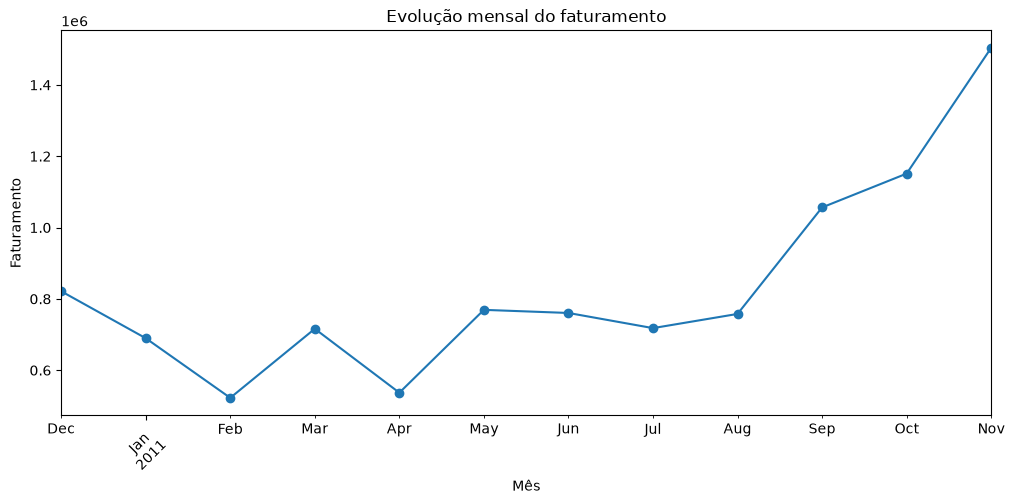

In [53]:
faturamento_mensal_completo.plot(
    kind="line",
    figsize=(12, 5),
    marker="o"
)

plt.title("Evolução mensal do faturamento")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.xticks(rotation=45)
plt.show()

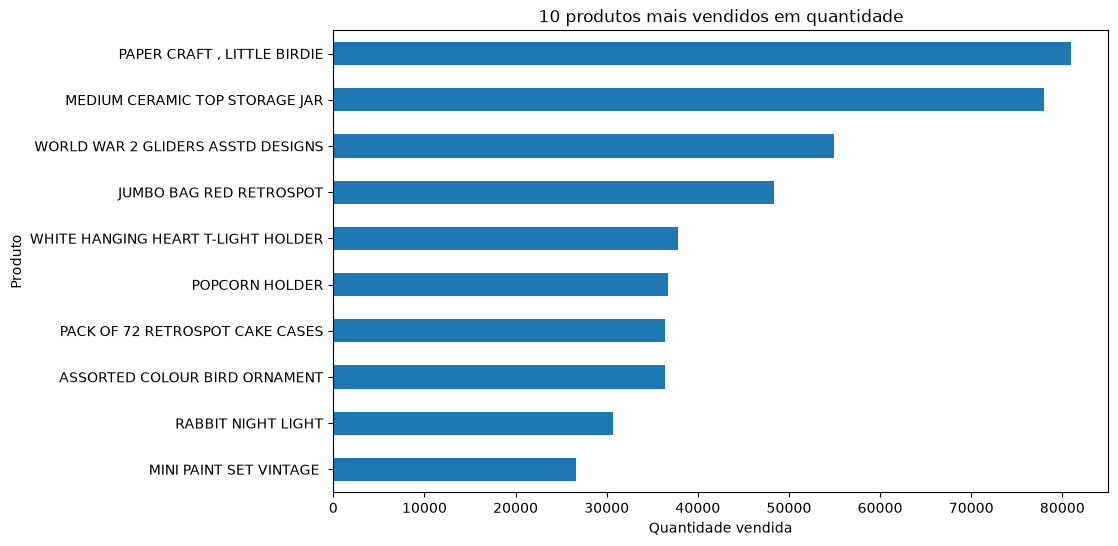

In [54]:
top_produtos_quantidade = (
    vendas_produtos.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

top_produtos_quantidade.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("10 produtos mais vendidos em quantidade")
plt.xlabel("Quantidade vendida")
plt.ylabel("Produto")
plt.show()

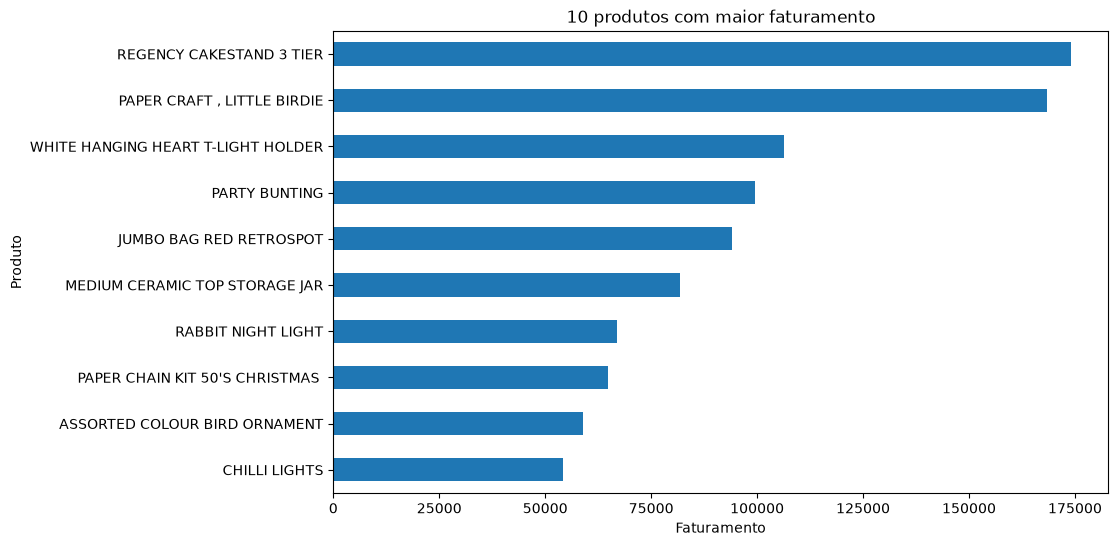

In [55]:
top_produtos_receita = (
    vendas_produtos.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

top_produtos_receita.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("10 produtos com maior faturamento")
plt.xlabel("Faturamento")
plt.ylabel("Produto")
plt.show()

## 28. Análise por país

O faturamento foi agregado por país e comparado ao total para calcular a participação percentual de cada mercado. O **Reino Unido concentra aproximadamente 84,59% da receita**, enquanto os demais países apresentam participações individuais muito menores, revelando forte concentração geográfica no mercado britânico.

In [56]:
# Faturamento por país
faturamento_pais = (
    vendas_limpas.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

faturamento_pais.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

In [57]:
# Percentual do faturamento por país
participacao_pais = (
    faturamento_pais / faturamento_pais.sum() * 100
)

participacao_pais.head(10)

Country
United Kingdom    84.586078
Netherlands        2.682234
EIRE               2.660567
Germany            2.148807
France             1.969772
Australia          1.301000
Spain              0.578443
Switzerland        0.536243
Belgium            0.387107
Sweden             0.360528
Name: TotalPrice, dtype: float64

## 29. Análise de clientes

Para os clientes identificados, foram calculados o faturamento acumulado, a quantidade de pedidos únicos e a participação dos dez maiores clientes na receita. O **top 10 representa aproximadamente 17,3%** da receita desses clientes, indicando concentração relevante, mas não dependência absoluta de um grupo muito pequeno.

In [58]:
clientes_faturamento = (
    vendas_limpas.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

clientes_faturamento.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

In [59]:
pedidos_por_cliente = (
    vendas_limpas.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

pedidos_por_cliente.head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [60]:
receita_clientes = clientes_faturamento.sort_values(ascending=False)

top_10_clientes = receita_clientes.head(10).sum()
receita_total_clientes = receita_clientes.sum()

percentual_top10 = top_10_clientes / receita_total_clientes * 100

print(
    "Percentual do faturamento gerado pelos 10 maiores clientes:",
    round(percentual_top10, 2),
    "%"
)

Percentual do faturamento gerado pelos 10 maiores clientes: 17.3 %


## 30. Análise por dia da semana

O faturamento foi agrupado e ordenado por dia da semana. **Terça-feira e quinta-feira** apresentaram os maiores valores; **sábado não possui vendas registradas** e domingo tem faturamento bem inferior ao dos dias úteis. Esse padrão pode refletir tanto o funcionamento da empresa quanto o comportamento de compra dos clientes.

In [61]:
ordem_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

faturamento_dia_semana = (
    vendas_limpas.groupby("DiaSemana")["TotalPrice"]
    .sum()
    .reindex(ordem_dias)
)

faturamento_dia_semana

DiaSemana
Monday       1775782.071
Tuesday      2175700.511
Wednesday    1847074.380
Thursday     2199292.570
Friday       1837470.491
Saturday             NaN
Sunday        806790.781
Name: TotalPrice, dtype: float64

## 31. Análise por horário

O agrupamento por hora mostra que a maior concentração de faturamento ocorre aproximadamente entre **10h e 15h**, seguida por queda significativa após as 16h. Os gráficos abaixo facilitam a comparação visual dos padrões semanais e intradiários.

In [62]:
faturamento_hora = (
    vendas_limpas.groupby("Hora")["TotalPrice"]
    .sum()
)

faturamento_hora

Hora
6           4.250
7       31059.210
8      283750.680
9      990054.991
10    1444814.771
11    1236573.290
12    1439324.660
13    1261195.200
14    1177907.521
15    1350333.310
16     752487.960
17     460963.921
18     144603.610
19      50204.950
20      18832.480
Name: TotalPrice, dtype: float64

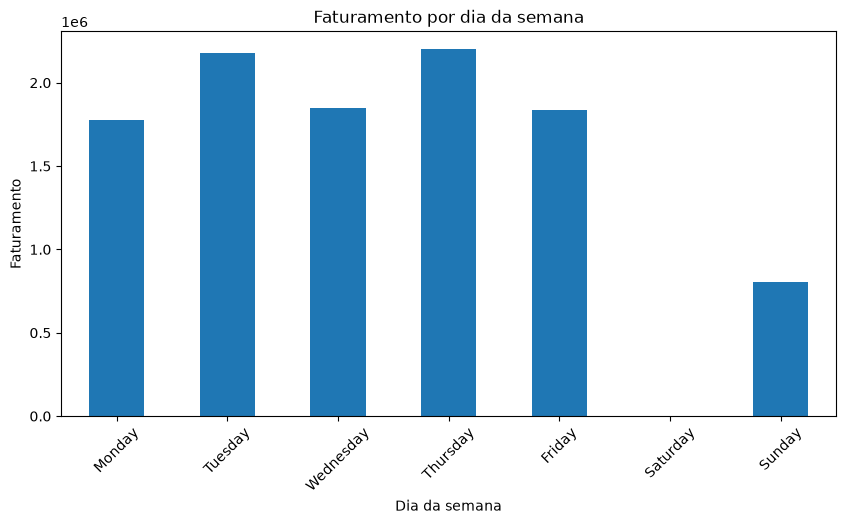

In [63]:
faturamento_dia_semana.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Faturamento por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Faturamento")
plt.xticks(rotation=45)
plt.show()


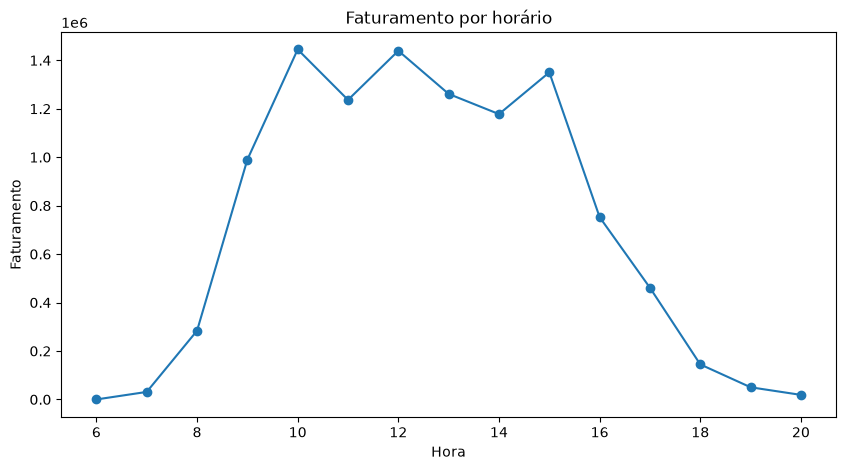

In [64]:
faturamento_hora.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Faturamento por horário")
plt.xlabel("Hora")
plt.ylabel("Faturamento")
plt.show()

## 32. Introdução à análise RFM

A análise **RFM** resume o comportamento de compra em três dimensões: **Recency**, número de dias desde a última compra; **Frequency**, quantidade de pedidos; e **Monetary**, valor total gasto. Dessa forma, a base transacional é transformada em uma tabela com uma linha por cliente.

A data de referência foi definida como um dia após a última data registrada no dataset, permitindo calcular a recência de todos os clientes em relação ao mesmo ponto temporal.

In [65]:
clientes_base = vendas_limpas.dropna(subset=["CustomerID"]).copy()

In [66]:
data_referencia = clientes_base["InvoiceDate"].max() + pd.Timedelta(days=1)

data_referencia

Timestamp('2011-12-10 12:50:00')

In [67]:
rfm = (
    clientes_base.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (data_referencia - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalPrice", "sum")
    )
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## 33. Estatísticas da base RFM

A base RFM contém **4.338 clientes**. A recência média é de aproximadamente **92,5 dias** e a mediana é **51 dias**; a frequência média é cerca de **4,27 pedidos** e a mediana, **2 pedidos**; o gasto médio é aproximadamente **2.048,69** e o mediano, **668,57**.

A diferença entre médias e medianas, especialmente em `Frequency` e `Monetary`, evidencia distribuições assimétricas, com poucos clientes muito acima do comportamento típico. Os rankings seguintes ajudam a inspecionar esses extremos.

In [68]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [69]:
rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary
CustomerID,,,
14646.0,2,73,280206.02
18102.0,1,60,259657.30
17450.0,8,46,194390.79
16446.0,1,2,168472.50
14911.0,1,201,143711.17
12415.0,24,21,124914.53
14156.0,10,55,117210.08
17511.0,3,31,91062.38
16029.0,39,63,80850.84


In [70]:
rfm.sort_values("Frequency", ascending=False).head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12748.0,1,209,33053.19
14911.0,1,201,143711.17
17841.0,2,124,40519.84
13089.0,3,97,58762.08
14606.0,1,93,12076.15
15311.0,1,91,60632.75
12971.0,4,86,11189.91
14646.0,2,73,280206.02
16029.0,39,63,80850.84


In [71]:
rfm.sort_values("Recency").head(10)

,Recency,Frequency,Monetary
CustomerID,,,
17364.0,1,11,4462.68
12433.0,1,7,13375.87
13599.0,1,21,5149.92
13536.0,1,7,3444.39
16933.0,1,2,563.23
17581.0,1,25,11025.24
15898.0,1,5,1383.83
16892.0,1,5,518.19
17644.0,1,11,2895.64


## 34. Scores RFM

Foram criados `R_score`, `F_score` e `M_score` pela divisão dos clientes em quintis de 1 a 5. Em recência, **quanto menor o número de dias, melhor a nota**; em frequência e valor monetário, **quanto maior o resultado, melhor a nota**.

As três notas foram concatenadas em `RFM_Score`, formando um código sintético do perfil de cada cliente.

In [72]:
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

In [73]:
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [74]:
rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [75]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

In [76]:
rfm.head(20)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112
12352.0,36,8,2506.04,3,5,5,355
12353.0,204,1,89.00,1,1,1,111
12354.0,232,1,1079.40,1,1,4,114
12355.0,214,1,459.40,1,1,2,112


## 35. Segmentação RFM baseada em regras

Uma função de regras de negócio classificou os clientes em **Campeões**, **Clientes fiéis**, **Clientes recentes / potenciais**, **Em risco**, **Alto valor em risco**, **Perdidos** e **Regulares**. Essa abordagem é determinística e interpretável; portanto, não constitui Machine Learning.

A distribuição obtida foi: **1.087 Regulares**, **957 Campeões**, **821 Perdidos**, **633 Clientes recentes / potenciais**, **503 Clientes fiéis**, **169 Alto valor em risco** e **168 Em risco**.

In [77]:
def classificar_cliente(row):
    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Campeões"

    elif r >= 3 and f >= 4:
        return "Clientes fiéis"

    elif r >= 4 and f <= 3:
        return "Clientes recentes / potenciais"

    elif r <= 2 and f >= 4 and m >= 4:
        return "Em risco"

    elif r <= 2 and m >= 4:
        return "Alto valor em risco"

    elif r <= 2 and f <= 2 and m <= 2:
        return "Perdidos"

    else:
        return "Regulares"

In [78]:
rfm["Segmento"] = rfm.apply(classificar_cliente, axis=1)

In [79]:
rfm["Segmento"].value_counts()

Segmento
Regulares                         1087
Campeões                           957
Perdidos                           821
Clientes recentes / potenciais     633
Clientes fiéis                     503
Alto valor em risco                169
Em risco                           168
Name: count, dtype: int64

## 36. Resumo comercial dos segmentos RFM

Os segmentos foram comparados por quantidade de clientes, recência média, frequência média, gasto médio e receita total. Os **Campeões** representam aproximadamente **22,06% dos clientes** e **65,17% da receita**, evidenciando forte concentração de valor nesse grupo.

Já **Alto valor em risco** reúne cerca de **3,9% dos clientes** e **5,15% da receita histórica**. Apesar de menor, esse grupo possui relevância comercial e potencial para ações de reativação.

In [80]:
resumo_segmentos = (
    rfm.groupby("Segmento")
    .agg(
        Clientes=("Segmento", "size"),
        Recency_media=("Recency", "mean"),
        Frequency_media=("Frequency", "mean"),
        Monetary_medio=("Monetary", "mean"),
        Receita_total=("Monetary", "sum")
    )
    .sort_values("Receita_total", ascending=False)
)

resumo_segmentos

,Clientes,Recency_media,Frequency_media,Monetary_medio,Receita_total
Segmento,,,,,
Campeões,957,12.824451,11.123302,6051.871202,5791640.740
Clientes fiéis,503,38.023857,5.077535,1780.619406,895651.561
Regulares,1087,113.363385,1.915363,575.581169,625656.731
Clientes recentes / potenciais,633,17.431280,1.785150,881.461722,557965.270
Alto valor em risco,169,162.023669,1.988166,2711.042905,458166.251
Em risco,168,125.559524,5.529762,2205.350298,370498.850
Perdidos,821,228.121803,1.042631,228.537748,187629.491


In [81]:
resumo_segmentos["Percentual_receita"] = (
    resumo_segmentos["Receita_total"]
    / resumo_segmentos["Receita_total"].sum()
    * 100
)

resumo_segmentos[
    ["Clientes", "Receita_total", "Percentual_receita"]
]

,Clientes,Receita_total,Percentual_receita
Segmento,,,
Campeões,957,5791640.740,65.168275
Clientes fiéis,503,895651.561,10.077985
Regulares,1087,625656.731,7.039969
Clientes recentes / potenciais,633,557965.270,6.278296
Alto valor em risco,169,458166.251,5.155345
Em risco,168,370498.850,4.168900
Perdidos,821,187629.491,2.111231


In [82]:
resumo_segmentos["Percentual_clientes"] = (
    resumo_segmentos["Clientes"]
    / resumo_segmentos["Clientes"].sum()
    * 100
)

resumo_segmentos[
    ["Clientes", "Percentual_clientes", "Receita_total", "Percentual_receita"]
]

,Clientes,Percentual_clientes,Receita_total,Percentual_receita
Segmento,,,,
Campeões,957,22.060858,5791640.740,65.168275
Clientes fiéis,503,11.595205,895651.561,10.077985
Regulares,1087,25.057630,625656.731,7.039969
Clientes recentes / potenciais,633,14.591978,557965.270,6.278296
Alto valor em risco,169,3.895805,458166.251,5.155345
Em risco,168,3.872752,370498.850,4.168900
Perdidos,821,18.925772,187629.491,2.111231


## 37. Introdução ao K-Means

Além das regras RFM, foi aplicado o **K-Means** para encontrar automaticamente grupos de clientes com base em `Recency`, `Frequency` e `Monetary`. Trata-se de uma técnica de **Machine Learning não supervisionado**, pois os grupos não são definidos previamente por rótulos conhecidos.

In [83]:
from sklearn.preprocessing import StandardScaler

## 38. Padronização dos dados

O `StandardScaler` foi usado para colocar as três variáveis RFM em escalas comparáveis. Essa etapa é necessária porque o K-Means utiliza distâncias: sem padronização, `Monetary`, por possuir valores numericamente maiores, poderia dominar a formação dos clusters.

In [84]:
rfm_ml = rfm[["Recency", "Frequency", "Monetary"]].copy()

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_ml)

## 39. Método do cotovelo inicial

Foram testados valores de `k` entre 1 e 10. O gráfico de inércia do método do cotovelo sugeriu inicialmente uma solução em torno de **3 ou 4 clusters**, ponto a partir do qual o ganho de compactação começa a diminuir.

In [85]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercias = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inercias.append(kmeans.inertia_)

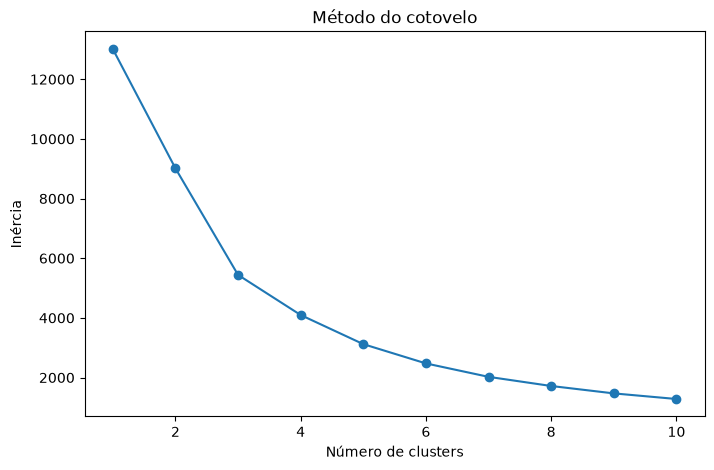

In [86]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inercias, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.title("Método do cotovelo")
plt.show()

## 40. Primeira segmentação com quatro clusters

A primeira aplicação com `k = 4` produziu: **Cluster 0 com 3.054 clientes**, **Cluster 1 com 1.067**, **Cluster 2 com 13** e **Cluster 3 com 204**. O grupo de apenas 13 clientes indicou forte influência de valores extremos, sobretudo em `Frequency` e `Monetary`.

In [87]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [88]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

In [89]:
perfil_clusters = (
    rfm.groupby("Cluster")
    .agg(
        Clientes=("Cluster", "size"),
        Recency_media=("Recency", "mean"),
        Frequency_media=("Frequency", "mean"),
        Monetary_medio=("Monetary", "mean")
    )
)

perfil_clusters

,Clientes,Recency_media,Frequency_media,Monetary_medio
Cluster,,,,
0,3054,43.702685,3.682711,1353.625312
1,1067,248.075914,1.552015,478.848773
2,13,7.384615,82.538462,127187.959231
3,204,15.500000,22.333333,12690.500392


## 41. Transformação logarítmica

Foi aplicada `np.log1p()` às variáveis RFM para reduzir a influência dos valores extremos sem excluir clientes importantes. Após a transformação, os dados foram novamente padronizados para manter as variáveis em escalas comparáveis.

In [90]:
rfm_ml_log = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

rfm_ml_log = np.log1p(rfm_ml_log)

In [91]:
scaler_log = StandardScaler()

rfm_scaled_log = scaler_log.fit_transform(rfm_ml_log)

## 42. Novo método do cotovelo e Silhouette Score

O método do cotovelo foi recalculado após a transformação logarítmica. Como medida complementar, o **Silhouette Score** avaliou a coesão interna e a separação entre clusters. Os principais resultados foram aproximadamente **0,433 para `k = 2`**, **0,337 para `k = 3`** e **0,338 para `k = 4`**.

Embora dois clusters apresentem a melhor separação matemática, apenas dois grupos ofereceriam pouca diferenciação para decisões comerciais.

In [92]:
inercias_log = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled_log)

    inercias_log.append(kmeans.inertia_)

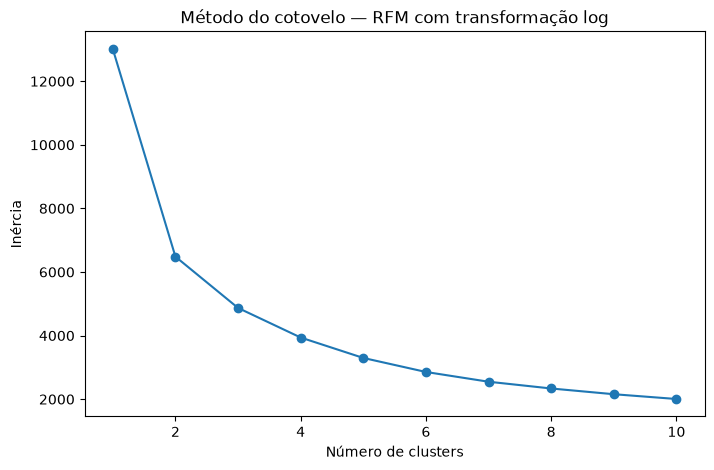

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inercias_log,
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.title("Método do cotovelo — RFM com transformação log")

plt.show()

In [94]:
from sklearn.metrics import silhouette_score

In [95]:
resultados_silhouette = {}

for k in range(2, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = modelo.fit_predict(rfm_scaled_log)

    score = silhouette_score(
        rfm_scaled_log,
        clusters
    )

    resultados_silhouette[k] = score

resultados_silhouette

{2: 0.4328265515350662,
 3: 0.3365174636950013,
 4: 0.33751704921261194,
 5: 0.3162001336222631,
 6: 0.3124091056438892,
 7: 0.30918598433785954,
 8: 0.30327504528060134,
 9: 0.281084500299107,
 10: 0.2766585172543556}

## 43. Comparação entre três e quatro clusters

Os perfis médios de `Recency`, `Frequency` e `Monetary` foram comparados em soluções com três e quatro grupos. A opção por **quatro clusters** foi mantida por produzir segmentos mais detalhados, úteis e interpretáveis para o negócio, mesmo com ganho matemático semelhante ao de três clusters.

In [96]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Cluster_3"] = kmeans_3.fit_predict(rfm_scaled_log)

perfil_3 = (
    rfm.groupby("Cluster_3")
    .agg(
        Clientes=("Cluster_3", "size"),
        Recency_media=("Recency", "mean"),
        Frequency_media=("Frequency", "mean"),
        Monetary_medio=("Monetary", "mean")
    )
)

perfil_3

,Clientes,Recency_media,Frequency_media,Monetary_medio
Cluster_3,,,,
0,769,17.062419,13.348505,7898.462003
1,1872,167.358440,1.352030,360.996448
2,1697,44.199764,3.380082,1259.579412


In [97]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster_4"] = kmeans_4.fit_predict(rfm_scaled_log)

perfil_4 = (
    rfm.groupby("Cluster_4")
    .agg(
        Clientes=("Cluster_4", "size"),
        Recency_media=("Recency", "mean"),
        Frequency_media=("Frequency", "mean"),
        Monetary_medio=("Monetary", "mean")
    )
)

perfil_4

,Clientes,Recency_media,Frequency_media,Monetary_medio
Cluster_4,,,,
0,713,12.171108,13.751753,8088.018331
1,1622,181.506782,1.316893,340.998626
2,837,17.698925,2.192354,557.322616
3,1166,71.635506,4.078902,1801.777893


## 44. Segmentação final por K-Means

Os quatro clusters finais foram interpretados e nomeados de acordo com seus perfis: **Alto valor / VIP**, **Inativos / Perdidos**, **Recentes / Baixo engajamento** e **Regulares / Intermediários**. A distribuição foi de **713**, **1.622**, **837** e **1.166 clientes**, respectivamente.

In [98]:
rfm["Cluster"] = kmeans_4.fit_predict(rfm_scaled_log)

nomes_clusters = {
    0: "Alto valor / VIP",
    1: "Inativos / Perdidos",
    2: "Recentes / Baixo engajamento",
    3: "Regulares / Intermediários"
}

rfm["Cluster_nome"] = rfm["Cluster"].map(nomes_clusters)

In [99]:
rfm["Cluster_nome"].value_counts()

Cluster_nome
Inativos / Perdidos             1622
Regulares / Intermediários      1166
Recentes / Baixo engajamento     837
Alto valor / VIP                 713
Name: count, dtype: int64

## 45. Perfil dos clusters finais

- **Alto valor / VIP:** recência média de ~12 dias, frequência de ~13,75, gasto médio de ~8.088 e receita total de ~5,77 milhões;
- **Regulares / Intermediários:** recência de ~72 dias, frequência de ~4,08, gasto médio de ~1.802 e receita de ~2,10 milhões;
- **Inativos / Perdidos:** recência de ~182 dias, frequência de ~1,32, gasto médio de ~341 e receita de ~553 mil;
- **Recentes / Baixo engajamento:** recência de ~18 dias, frequência de ~2,19, gasto médio de ~557 e receita de ~466 mil.

In [100]:
resumo_clusters = (
    rfm.groupby("Cluster_nome")
    .agg(
        Clientes=("Cluster_nome", "size"),
        Recency_media=("Recency", "mean"),
        Frequency_media=("Frequency", "mean"),
        Monetary_medio=("Monetary", "mean"),
        Receita_total=("Monetary", "sum")
    )
    .sort_values("Receita_total", ascending=False)
)

resumo_clusters

,Clientes,Recency_media,Frequency_media,Monetary_medio,Receita_total
Cluster_nome,,,,,
Alto valor / VIP,713,12.171108,13.751753,8088.018331,5766757.070
Regulares / Intermediários,1166,71.635506,4.078902,1801.777893,2100873.023
Inativos / Perdidos,1622,181.506782,1.316893,340.998626,553099.771
Recentes / Baixo engajamento,837,17.698925,2.192354,557.322616,466479.030


## 46. Visualização dos clusters

Os gráficos de dispersão comparam **Frequency × Monetary** e **Recency × Monetary**, permitindo observar diferenças de frequência, valor e atividade entre os grupos. Como os clientes VIP apresentam valores muito elevados, eles comprimem visualmente os demais clusters — efeito esperado diante da assimetria dos dados.

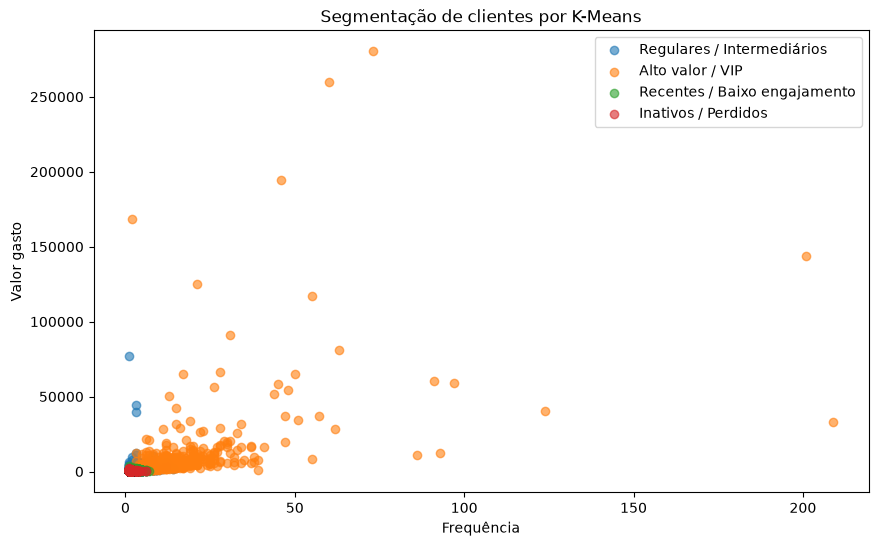

In [101]:
plt.figure(figsize=(10, 6))

for nome in rfm["Cluster_nome"].unique():
    dados = rfm[rfm["Cluster_nome"] == nome]
    plt.scatter(
        dados["Frequency"],
        dados["Monetary"],
        label=nome,
        alpha=0.6
    )

plt.xlabel("Frequência")
plt.ylabel("Valor gasto")
plt.title("Segmentação de clientes por K-Means")
plt.legend()
plt.show()

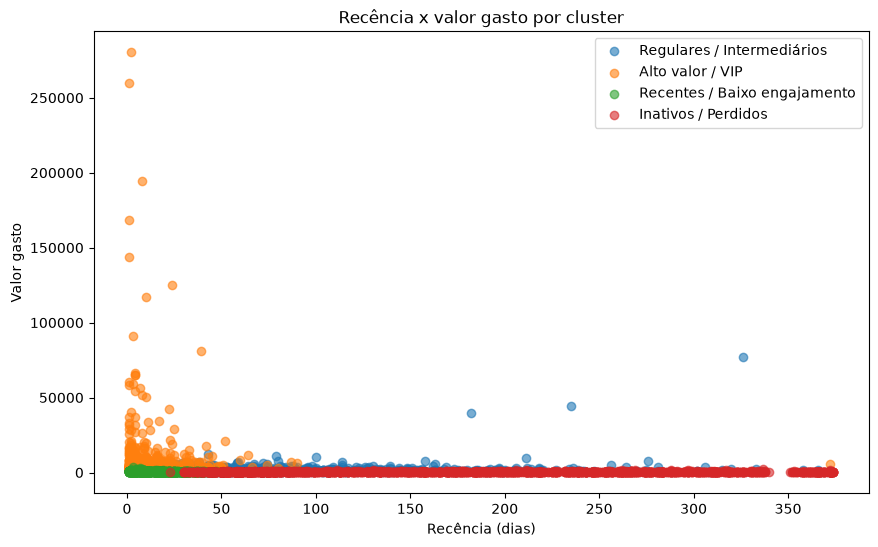

In [102]:
plt.figure(figsize=(10, 6))

for nome in rfm["Cluster_nome"].unique():
    dados = rfm[rfm["Cluster_nome"] == nome]
    plt.scatter(
        dados["Recency"],
        dados["Monetary"],
        label=nome,
        alpha=0.6
    )

plt.xlabel("Recência (dias)")
plt.ylabel("Valor gasto")
plt.title("Recência x valor gasto por cluster")
plt.legend()
plt.show()

## 47. Participação da receita por cluster

A receita está distribuída da seguinte forma: **Alto valor / VIP, ~64,89%**; **Regulares / Intermediários, ~23,64%**; **Inativos / Perdidos, ~6,22%**; e **Recentes / Baixo engajamento, ~5,25%**. A concentração no grupo VIP reforça sua importância estratégica para ações de retenção.

In [103]:
receita_cluster = (
    rfm.groupby("Cluster_nome")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

participacao_cluster = receita_cluster / receita_cluster.sum() * 100

participacao_cluster

Cluster_nome
Alto valor / VIP                64.888281
Regulares / Intermediários      23.639289
Inativos / Perdidos              6.223549
Recentes / Baixo engajamento     5.248881
Name: Monetary, dtype: float64

## 48. Comparação: RFM por regras × K-Means

O projeto utilizou duas abordagens complementares. O **RFM por regras** é simples, controlável e fácil de explicar; o **K-Means** é um método não supervisionado que identifica padrões automaticamente. Comparar os resultados ajuda a validar os perfis encontrados e demonstra que o Machine Learning foi aplicado com interpretação e contexto de negócio.

### Preparação exploratória da série diária

Como observação para uma etapa futura, o faturamento foi agregado por dia, seu intervalo temporal foi conferido e a série foi visualizada. Este bloco apenas examina a estrutura diária já existente; nenhuma previsão ou nova modelagem é realizada aqui.

In [104]:
vendas_diarias = (
    vendas_limpas
    .set_index("InvoiceDate")
    .resample("D")["TotalPrice"]
    .sum()
)

vendas_diarias.head()

InvoiceDate
2010-12-01    58776.79
2010-12-02    47629.42
2010-12-03    46898.63
2010-12-04        0.00
2010-12-05    31364.63
Freq: D, Name: TotalPrice, dtype: float64

In [105]:
print("Início:", vendas_diarias.index.min())
print("Fim:", vendas_diarias.index.max())
print("Número de dias:", len(vendas_diarias))

Início: 2010-12-01 00:00:00
Fim: 2011-12-09 00:00:00
Número de dias: 374


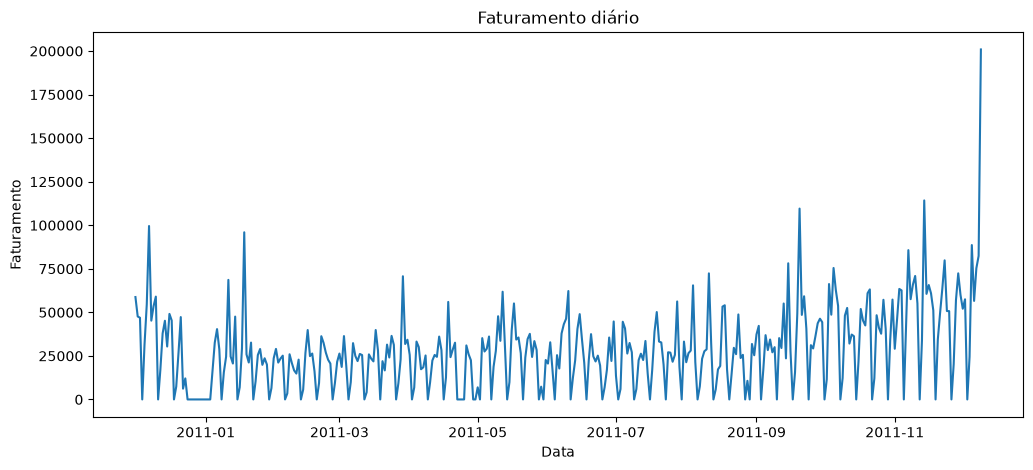

In [106]:
plt.figure(figsize=(12, 5))
plt.plot(vendas_diarias.index, vendas_diarias.values)

plt.title("Faturamento diário")
plt.xlabel("Data")
plt.ylabel("Faturamento")
plt.show()

## Conclusão da etapa de segmentação de clientes

A análise identificou padrões claros de comportamento e mostrou que uma parcela relativamente pequena dos clientes concentra a maior parte do valor: o grupo **Alto valor / VIP representa aproximadamente 65% da receita**. Também foram reconhecidos grupos com potencial específico para retenção, reativação e aumento de frequência.

A segmentação RFM por regras e o K-Means produziram perfis comercialmente coerentes e complementares, unindo interpretabilidade de negócio e descoberta automática de padrões. Na sequência, é conduzido um experimento de previsão de faturamento para avaliar a viabilidade da série disponível.

## 49. Experimento de previsão diária de faturamento

A série diária é transformada em uma base supervisionada para avaliar se o histórico disponível permite antecipar o faturamento de curto prazo. O objetivo desta etapa é comparar referências simples com modelos de regressão, sem assumir que maior complexidade produzirá necessariamente melhor desempenho.

As variáveis de calendário representam o dia da semana, o mês, o dia do mês e a semana do ano. O alvo permanece `TotalPrice`, agregado por dia.

In [107]:
df_modelo = vendas_diarias.reset_index()

df_modelo["DiaSemana"] = df_modelo["InvoiceDate"].dt.dayofweek
df_modelo["Mes"] = df_modelo["InvoiceDate"].dt.month
df_modelo["DiaMes"] = df_modelo["InvoiceDate"].dt.day
df_modelo["SemanaAno"] = df_modelo["InvoiceDate"].dt.isocalendar().week.astype(int)

### Engenharia de atributos temporais

São criados atrasos de 1, 7 e 14 dias (`lags`) e médias móveis de 7 e 14 dias. O uso de `shift(1)` nas médias garante que o valor do próprio dia previsto não seja utilizado como entrada, reduzindo o risco de vazamento do alvo.

In [108]:
df_modelo["Lag_1"] = df_modelo["TotalPrice"].shift(1)
df_modelo["Lag_7"] = df_modelo["TotalPrice"].shift(7)
df_modelo["Lag_14"] = df_modelo["TotalPrice"].shift(14)

In [109]:
df_modelo["Media_7"] = (
    df_modelo["TotalPrice"]
    .shift(1)
    .rolling(7)
    .mean()
)

df_modelo["Media_14"] = (
    df_modelo["TotalPrice"]
    .shift(1)
    .rolling(14)
    .mean()
)

In [110]:
df_modelo.head(20)

,InvoiceDate,TotalPrice,DiaSemana,Mes,DiaMes,SemanaAno,Lag_1,Lag_7,Lag_14,Media_7,Media_14
0,2010-12-01,58776.79,2,12,1,48,NaN,NaN,NaN,NaN,NaN
1,2010-12-02,47629.42,3,12,2,48,58776.79,NaN,NaN,NaN,NaN
2,2010-12-03,46898.63,4,12,3,48,47629.42,NaN,NaN,NaN,NaN
3,2010-12-04,0.00,5,12,4,48,46898.63,NaN,NaN,NaN,NaN
4,2010-12-05,31364.63,6,12,5,48,0.00,NaN,NaN,NaN,NaN
5,2010-12-06,54624.15,0,12,6,49,31364.63,NaN,NaN,NaN,NaN
6,2010-12-07,99553.85,1,12,7,49,54624.15,NaN,NaN,NaN,NaN
7,2010-12-08,45235.36,2,12,8,49,99553.85,58776.79,NaN,48406.781429,NaN
8,2010-12-09,53548.19,3,12,9,49,45235.36,47629.42,NaN,46472.291429,NaN
9,2010-12-10,59021.02,4,12,10,49,53548.19,46898.63,NaN,47317.830000,NaN


### Preparação e divisão temporal

As primeiras linhas sem histórico suficiente para calcular atrasos e médias móveis são removidas. A base resultante contém **360 dias** e nove atributos preditivos. A divisão mantém a ordem cronológica: os primeiros 80% formam o treino e os 20% finais formam o teste, totalizando **288 observações de treino e 72 de teste**.

In [111]:
df_modelo = df_modelo.dropna().copy()

In [112]:
df_modelo.shape

(360, 11)

In [113]:
features = [
    "DiaSemana",
    "Mes",
    "DiaMes",
    "SemanaAno",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Media_7",
    "Media_14"
]

X = df_modelo[features]
y = df_modelo["TotalPrice"]

In [114]:
tamanho_treino = int(len(df_modelo) * 0.8)

X_train = X.iloc[:tamanho_treino]
X_test = X.iloc[tamanho_treino:]

y_train = y.iloc[:tamanho_treino]
y_test = y.iloc[tamanho_treino:]

In [115]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (288, 9)
Teste: (72, 9)


### Baseline sazonal semanal

A primeira referência utiliza o faturamento observado sete dias antes (`Lag_7`) como previsão. Esse baseline captura o padrão semanal e estabelece o desempenho mínimo que um modelo mais complexo deve superar. Foram obtidos **MAE de 14.003,74**, **RMSE de 24.045,95** e **R² de 0,4025**.

In [116]:
baseline_pred = X_test["Lag_7"]

In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)
r2_baseline = r2_score(y_test, baseline_pred)

print("Baseline")
print("MAE:", round(mae_baseline, 2))
print("RMSE:", round(rmse_baseline, 2))
print("R²:", round(r2_baseline, 4))

Baseline
MAE: 14003.74
RMSE: 24045.95
R²: 0.4025


### Random Forest para regressão

O `RandomForestRegressor` é treinado com restrições de profundidade e tamanho mínimo das folhas para limitar a complexidade. No teste, o modelo apresentou **MAE de 15.077,87**, **RMSE de 25.182,03** e **R² de 0,3447**, ficando abaixo do baseline semanal.

In [118]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=3
)

modelo_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [119]:
pred_rf = modelo_rf.predict(X_test)

In [120]:
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(
    mean_squared_error(y_test, pred_rf)
)
r2_rf = r2_score(y_test, pred_rf)

print("Random Forest")
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²:", round(r2_rf, 4))

Random Forest
MAE: 15077.87
RMSE: 25182.03
R²: 0.3447


### Comparação e inspeção visual

As métricas do baseline e da Random Forest são reunidas em uma tabela. Em seguida, os valores reais e previstos são alinhados às datas do período de teste para inspecionar visualmente a capacidade do modelo de acompanhar oscilações e picos de faturamento.

In [121]:
comparacao = pd.DataFrame({
    "Modelo": ["Baseline Lag 7", "Random Forest"],
    "MAE": [mae_baseline, mae_rf],
    "RMSE": [rmse_baseline, rmse_rf],
    "R2": [r2_baseline, r2_rf]
})

comparacao

,Modelo,MAE,RMSE,R2
0,Baseline Lag 7,14003.736667,24045.948502,0.402472
1,Random Forest,15077.874470,25182.029846,0.344676


In [122]:
resultado_teste = df_modelo.iloc[tamanho_treino:].copy()

resultado_teste["Real"] = y_test.values
resultado_teste["Baseline"] = baseline_pred.values
resultado_teste["RandomForest"] = pred_rf

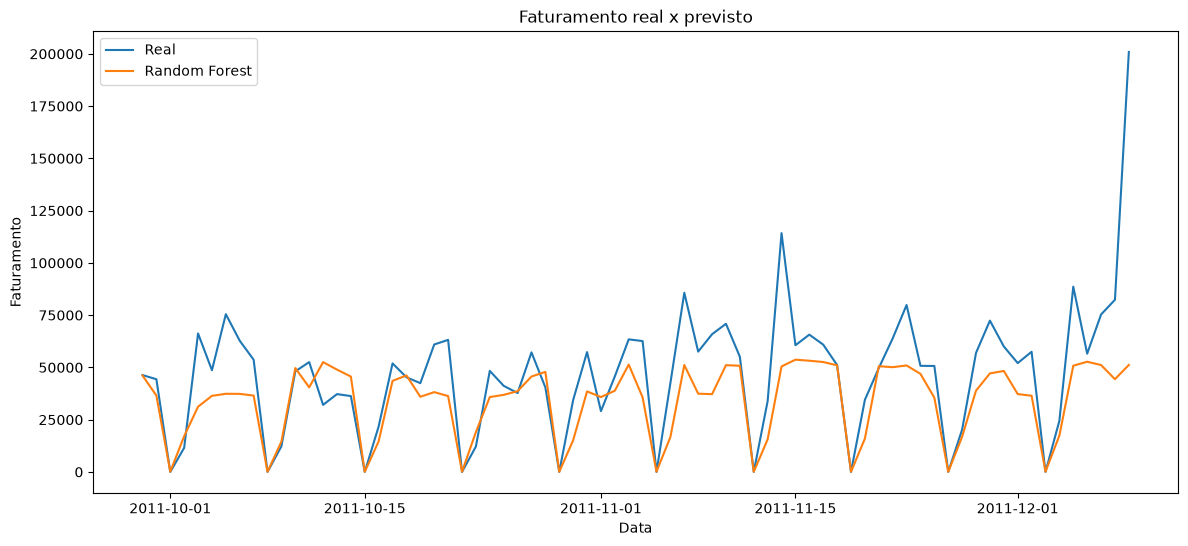

In [123]:
plt.figure(figsize=(14, 6))

plt.plot(
    resultado_teste["InvoiceDate"],
    resultado_teste["Real"],
    label="Real"
)

plt.plot(
    resultado_teste["InvoiceDate"],
    resultado_teste["RandomForest"],
    label="Random Forest"
)

plt.xlabel("Data")
plt.ylabel("Faturamento")
plt.title("Faturamento real x previsto")
plt.legend()

plt.show()

### Importância das variáveis

A importância calculada pela Random Forest indica quais atributos mais contribuíram para as divisões das árvores. `Lag_7` e `DiaSemana` aparecem como os fatores dominantes, reforçando a presença de um padrão semanal na série. Essa medida descreve o uso das variáveis pelo modelo, mas não implica causalidade.

In [124]:
importances = pd.Series(
    modelo_rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importances

Lag_7        0.335393
DiaSemana    0.293657
Media_7      0.086298
Lag_1        0.068978
SemanaAno    0.060195
Lag_14       0.053157
Media_14     0.045617
DiaMes       0.043006
Mes          0.013700
dtype: float64

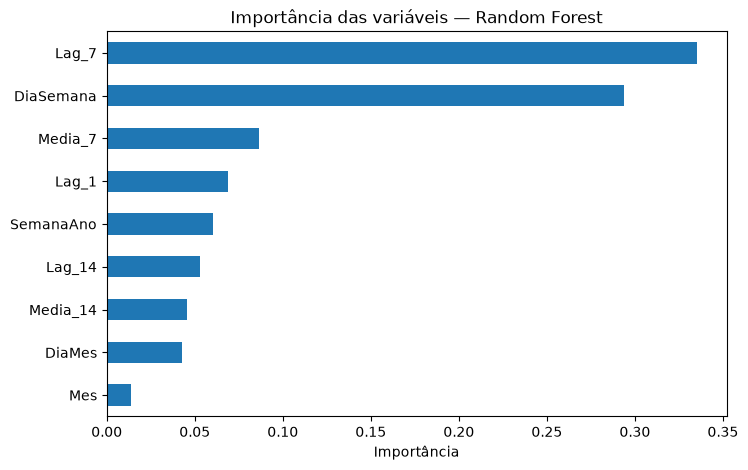

In [125]:
importances.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Importância das variáveis — Random Forest")
plt.xlabel("Importância")
plt.show()

### HistGradientBoosting e comparação dos regressores

O `HistGradientBoostingRegressor` é avaliado como alternativa baseada em boosting. O resultado foi **MAE de 19.565,79**, **RMSE de 28.868,86** e **R² de 0,1387**. A comparação confirma que, neste recorte, nenhum dos modelos de Machine Learning superou o baseline de sete dias.

> A célula de treinamento do HistGradientBoosting aparece duas vezes no experimento original. A repetição foi preservada para não alterar o código existente, mas não representa dois modelos diferentes.

In [126]:
from sklearn.ensemble import HistGradientBoostingRegressor

modelo_hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

modelo_hgb.fit(X_train, y_train)

pred_hgb = modelo_hgb.predict(X_test)

In [127]:
from sklearn.ensemble import HistGradientBoostingRegressor

modelo_hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

modelo_hgb.fit(X_train, y_train)

pred_hgb = modelo_hgb.predict(X_test)

In [128]:
mae_hgb = mean_absolute_error(y_test, pred_hgb)

rmse_hgb = np.sqrt(
    mean_squared_error(y_test, pred_hgb)
)

r2_hgb = r2_score(y_test, pred_hgb)

print("HistGradientBoosting")
print("MAE:", round(mae_hgb, 2))
print("RMSE:", round(rmse_hgb, 2))
print("R²:", round(r2_hgb, 4))

HistGradientBoosting
MAE: 19565.79
RMSE: 28868.86
R²: 0.1387


In [129]:
comparacao = pd.DataFrame({
    "Modelo": [
        "Baseline Lag 7",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "MAE": [
        mae_baseline,
        mae_rf,
        mae_hgb
    ],
    "RMSE": [
        rmse_baseline,
        rmse_rf,
        rmse_hgb
    ],
    "R2": [
        r2_baseline,
        r2_rf,
        r2_hgb
    ]
})

comparacao

,Modelo,MAE,RMSE,R2
0,Baseline Lag 7,14003.736667,24045.948502,0.402472
1,Random Forest,15077.874470,25182.029846,0.344676
2,HistGradientBoosting,19565.792755,28868.858253,0.138741


## 50. Investigação dos dias sem faturamento

Foram encontrados **67 dias com faturamento zero**. A distribuição por dia da semana mostra que 51 correspondem a sábados, indicando ausência sistemática de operação nesse dia. O agrupamento também compara quantidade de observações, dias zerados e faturamento médio para cada dia da semana.

In [130]:
dias_zero = df_modelo[df_modelo["TotalPrice"] == 0]

print("Quantidade de dias com faturamento zero:", len(dias_zero))

Quantidade de dias com faturamento zero: 67


In [131]:
dias_zero["DiaSemana"].value_counts().sort_index()

DiaSemana
0     6
1     1
2     1
3     1
4     4
5    51
6     3
Name: count, dtype: int64

In [132]:
df_modelo.groupby("DiaSemana").agg(
    Dias=("TotalPrice", "size"),
    Dias_zero=("TotalPrice", lambda x: (x == 0).sum()),
    Faturamento_medio=("TotalPrice", "mean")
)

,Dias,Dias_zero,Faturamento_medio
DiaSemana,,,
0,51,6,33004.226490
1,51,1,39823.119627
2,52,1,33520.427500
3,52,1,40348.364615
4,52,4,33299.054635
5,51,51,0.000000
6,51,3,14868.637275


### Modelagem restrita aos dias de operação

Para verificar se os sábados zerados favoreciam artificialmente o padrão semanal, esse dia é removido e o experimento é repetido. Restam **309 observações**, das quais 16 ainda possuem faturamento zero. Nesse cenário, o baseline alcançou **R² de 0,0544** e a Random Forest, **R² de -0,0157**, sem ganho preditivo relevante.

In [133]:
df_modelo_operacao = df_modelo[
    df_modelo["DiaSemana"] != 5
].copy()

In [134]:
df_modelo_operacao.shape

(309, 11)

In [135]:
(df_modelo_operacao["TotalPrice"] == 0).sum()

np.int64(16)

In [136]:
X_operacao = df_modelo_operacao[features]
y_operacao = df_modelo_operacao["TotalPrice"]

In [137]:
tamanho_treino_operacao = int(len(df_modelo_operacao) * 0.8)

X_train_op = X_operacao.iloc[:tamanho_treino_operacao]
X_test_op = X_operacao.iloc[tamanho_treino_operacao:]

y_train_op = y_operacao.iloc[:tamanho_treino_operacao]
y_test_op = y_operacao.iloc[tamanho_treino_operacao:]

In [138]:
baseline_op = X_test_op["Lag_7"]

mae_baseline_op = mean_absolute_error(y_test_op, baseline_op)
rmse_baseline_op = np.sqrt(mean_squared_error(y_test_op, baseline_op))
r2_baseline_op = r2_score(y_test_op, baseline_op)

print("Baseline - dias de operação")
print("MAE:", round(mae_baseline_op, 2))
print("RMSE:", round(rmse_baseline_op, 2))
print("R²:", round(r2_baseline_op, 4))

Baseline - dias de operação
MAE: 16262.4
RMSE: 25912.68
R²: 0.0544


In [139]:
modelo_rf_op = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=3
)

modelo_rf_op.fit(X_train_op, y_train_op)

pred_rf_op = modelo_rf_op.predict(X_test_op)

mae_rf_op = mean_absolute_error(y_test_op, pred_rf_op)
rmse_rf_op = np.sqrt(mean_squared_error(y_test_op, pred_rf_op))
r2_rf_op = r2_score(y_test_op, pred_rf_op)

print("Random Forest - dias de operação")
print("MAE:", round(mae_rf_op, 2))
print("RMSE:", round(rmse_rf_op, 2))
print("R²:", round(r2_rf_op, 4))

Random Forest - dias de operação
MAE: 17443.64
RMSE: 26855.58
R²: -0.0157


## 51. Regressão linear com tendência

Uma variável sequencial de tendência é adicionada para representar a evolução temporal da série. A regressão linear utiliza tendência, dia da semana, atraso de sete dias e média móvel de sete dias. O modelo obteve **MAE de 16.473,26**, **RMSE de 25.594,06** e **R² de 0,3231**, também abaixo do baseline semanal.

In [140]:
df_modelo

,InvoiceDate,TotalPrice,DiaSemana,Mes,DiaMes,SemanaAno,Lag_1,Lag_7,Lag_14,Media_7,Media_14
14,2010-12-15,30384.37,2,12,15,50,45167.56,45235.36,58776.79,36862.878571,42634.830000
15,2010-12-16,49114.14,3,12,16,50,30384.37,53548.19,47629.42,34741.308571,40606.800000
16,2010-12-17,45338.13,4,12,17,50,49114.14,59021.02,46898.63,34107.872857,40712.851429
17,2010-12-18,0.00,5,12,18,50,45338.13,0.00,0.00,32153.174286,40601.387143
18,2010-12-19,7410.47,6,12,19,50,0.00,17125.65,31364.63,32153.174286,40601.387143
...,...,...,...,...,...,...,...,...,...,...,...
369,2011-12-05,88620.84,0,12,5,49,24477.47,56965.73,49674.60,46199.814286,45608.054286
370,2011-12-06,56558.83,1,12,6,49,88620.84,72384.82,63863.48,50721.972857,48389.928571
371,2011-12-07,75315.55,2,12,7,49,56558.83,60025.57,79847.00,48461.117143,47868.167857
372,2011-12-08,82371.55,3,12,8,49,75315.55,52068.63,50759.21,50645.400000,47544.492857


In [141]:
df_modelo["Tendencia"] = range(len(df_modelo))

In [142]:
from sklearn.linear_model import LinearRegression

In [143]:
features_linear = [
    "Tendencia",
    "DiaSemana",
    "Lag_7",
    "Media_7"
]

In [144]:
X_linear = df_modelo[features_linear]
y_linear = df_modelo["TotalPrice"]

tamanho_treino_linear = int(len(df_modelo) * 0.8)

X_train_linear = X_linear.iloc[:tamanho_treino_linear]
X_test_linear = X_linear.iloc[tamanho_treino_linear:]

y_train_linear = y_linear.iloc[:tamanho_treino_linear]
y_test_linear = y_linear.iloc[tamanho_treino_linear:]

In [145]:
modelo_linear = LinearRegression()

modelo_linear.fit(
    X_train_linear,
    y_train_linear
)

pred_linear = modelo_linear.predict(X_test_linear)

In [146]:
mae_linear = mean_absolute_error(
    y_test_linear,
    pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test_linear,
        pred_linear
    )
)

r2_linear = r2_score(
    y_test_linear,
    pred_linear
)

print("Regressão Linear")
print("MAE:", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²:", round(r2_linear, 4))

Regressão Linear
MAE: 16473.26
RMSE: 25594.06
R²: 0.3231


In [147]:
comparacao = pd.DataFrame({
    "Modelo": [
        "Baseline Lag 7",
        "Random Forest",
        "HistGradientBoosting",
        "Regressão Linear"
    ],
    "MAE": [
        mae_baseline,
        mae_rf,
        mae_hgb,
        mae_linear
    ],
    "RMSE": [
        rmse_baseline,
        rmse_rf,
        rmse_hgb,
        rmse_linear
    ],
    "R2": [
        r2_baseline,
        r2_rf,
        r2_hgb,
        r2_linear
    ]
})

comparacao

,Modelo,MAE,RMSE,R2
0,Baseline Lag 7,14003.736667,24045.948502,0.402472
1,Random Forest,15077.874470,25182.029846,0.344676
2,HistGradientBoosting,19565.792755,28868.858253,0.138741
3,Regressão Linear,16473.263062,25594.058690,0.323056


## 52. Experimento de previsão semanal

Como alternativa à granularidade diária, o faturamento é agregado por semana. A série contém **54 semanas**, o que reduz ruídos diários, mas também diminui de forma importante o número de observações disponíveis para treinamento e avaliação.

In [148]:
vendas_semanais = (
    vendas_limpas
    .set_index("InvoiceDate")
    .resample("W")["TotalPrice"]
    .sum()
)

vendas_semanais.head()

InvoiceDate
2010-12-05    184669.47
2010-12-12    329108.22
2010-12-19    215357.04
2010-12-26     92318.00
2011-01-02         0.00
Freq: W-SUN, Name: TotalPrice, dtype: float64

In [149]:
print("Início:", vendas_semanais.index.min())
print("Fim:", vendas_semanais.index.max())
print("Número de semanas:", len(vendas_semanais))

Início: 2010-12-05 00:00:00
Fim: 2011-12-11 00:00:00
Número de semanas: 54


In [150]:
df_semanal = vendas_semanais.reset_index()

In [151]:
df_semanal["SemanaAno"] = df_semanal["InvoiceDate"].dt.isocalendar().week.astype(int)
df_semanal["Mes"] = df_semanal["InvoiceDate"].dt.month
df_semanal["Tendencia"] = range(len(df_semanal))

In [152]:
df_semanal["Lag_1"] = df_semanal["TotalPrice"].shift(1)
df_semanal["Lag_2"] = df_semanal["TotalPrice"].shift(2)
df_semanal["Lag_4"] = df_semanal["TotalPrice"].shift(4)

In [153]:

df_semanal["Media_4"] = (
    df_semanal["TotalPrice"]
    .shift(1)
    .rolling(4)
    .mean()
)

df_semanal["Media_8"] = (
    df_semanal["TotalPrice"]
    .shift(1)
    .rolling(8)
    .mean()
)

In [154]:
df_semanal = df_semanal.dropna().copy()

df_semanal.shape

(46, 10)

In [155]:
df_semanal.head(10)

,InvoiceDate,TotalPrice,SemanaAno,Mes,Tendencia,Lag_1,Lag_2,Lag_4,Media_4,Media_8
8,2011-01-30,124534.22,4,1,8,215227.01,192991.95,0.00,135412.1700,170387.67625
9,2011-02-06,125847.36,5,2,9,124534.22,215227.01,133429.72,166545.7250,162870.77000
10,2011-02-13,106893.22,6,2,10,125847.36,124534.22,192991.95,164650.1350,137463.16250
11,2011-02-20,143354.21,7,2,11,106893.22,125847.36,215227.01,143125.4525,123905.18500
12,2011-02-27,148404.19,8,2,12,143354.21,106893.22,124534.22,125157.2525,130284.71125
13,2011-03-06,132503.55,9,3,13,148404.19,143354.21,125847.36,131124.7450,148835.23500
14,2011-03-13,135076.46,10,3,14,132503.55,148404.19,106893.22,132788.7925,148719.46375
15,2011-03-20,161082.62,11,3,15,135076.46,132503.55,143354.21,139834.6025,141480.02750
16,2011-03-27,149292.66,12,3,16,161082.62,135076.46,148404.19,144266.7050,134711.97875
17,2011-04-03,192398.08,13,4,17,149292.66,161082.62,132503.55,144488.8225,137806.78375


### Atributos e divisão temporal da série semanal

São criados atributos de calendário, tendência, atrasos de uma, duas e quatro semanas e médias móveis de quatro e oito semanas. Após a remoção das linhas iniciais incompletas, restam **46 semanas**: 36 para treino e apenas 10 para teste. O tamanho reduzido limita a estabilidade das métricas.

In [156]:
features_semanais = [
    "SemanaAno",
    "Mes",
    "Tendencia",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Media_4",
    "Media_8"
]

X_sem = df_semanal[features_semanais]
y_sem = df_semanal["TotalPrice"]

tamanho_treino_sem = int(len(df_semanal) * 0.8)

X_train_sem = X_sem.iloc[:tamanho_treino_sem]
X_test_sem = X_sem.iloc[tamanho_treino_sem:]

y_train_sem = y_sem.iloc[:tamanho_treino_sem]
y_test_sem = y_sem.iloc[tamanho_treino_sem:]

print("Treino:", X_train_sem.shape)
print("Teste:", X_test_sem.shape)

Treino: (36, 8)
Teste: (10, 8)


### Baselines e modelos semanais

A avaliação compara o faturamento da semana anterior, o atraso de quatro semanas, regressão linear e Random Forest. O baseline de uma semana apresentou o menor MAE entre os modelos comparados, mas todos os valores de R² foram negativos. Esse resultado indica desempenho inferior à previsão pela média do período de teste e evidencia que o histórico semanal é insuficiente para uma solução robusta.

In [157]:
baseline_sem = X_test_sem["Lag_1"]

mae_baseline_sem = mean_absolute_error(y_test_sem, baseline_sem)
rmse_baseline_sem = np.sqrt(
    mean_squared_error(y_test_sem, baseline_sem)
)
r2_baseline_sem = r2_score(y_test_sem, baseline_sem)

print("Baseline semanal")
print("MAE:", round(mae_baseline_sem, 2))
print("RMSE:", round(rmse_baseline_sem, 2))
print("R²:", round(r2_baseline_sem, 4))

Baseline semanal
MAE: 65163.32
RMSE: 81814.46
R²: -0.2283


In [158]:
baseline_4_sem = X_test_sem["Lag_4"]

print(
    "MAE Lag 4:",
    round(mean_absolute_error(y_test_sem, baseline_4_sem), 2)
)

MAE Lag 4: 72283.71


In [159]:
modelo_linear_sem = LinearRegression()

modelo_linear_sem.fit(
    X_train_sem,
    y_train_sem
)

pred_linear_sem = modelo_linear_sem.predict(X_test_sem)

mae_linear_sem = mean_absolute_error(y_test_sem, pred_linear_sem)
rmse_linear_sem = np.sqrt(
    mean_squared_error(y_test_sem, pred_linear_sem)
)
r2_linear_sem = r2_score(y_test_sem, pred_linear_sem)

print("Regressão Linear semanal")
print("MAE:", round(mae_linear_sem, 2))
print("RMSE:", round(rmse_linear_sem, 2))
print("R²:", round(r2_linear_sem, 4))

Regressão Linear semanal
MAE: 159852.26
RMSE: 180981.19
R²: -5.0104


In [160]:
modelo_rf_sem = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    random_state=42
)

modelo_rf_sem.fit(
    X_train_sem,
    y_train_sem
)

pred_rf_sem = modelo_rf_sem.predict(X_test_sem)

mae_rf_sem = mean_absolute_error(y_test_sem, pred_rf_sem)
rmse_rf_sem = np.sqrt(
    mean_squared_error(y_test_sem, pred_rf_sem)
)
r2_rf_sem = r2_score(y_test_sem, pred_rf_sem)

print("Random Forest semanal")
print("MAE:", round(mae_rf_sem, 2))
print("RMSE:", round(rmse_rf_sem, 2))
print("R²:", round(r2_rf_sem, 4))

Random Forest semanal
MAE: 89244.92
RMSE: 113536.81
R²: -1.3654


In [161]:
comparacao_semanal = pd.DataFrame({
    "Modelo": [
        "Baseline Lag 1",
        "Regressão Linear",
        "Random Forest"
    ],
    "MAE": [
        mae_baseline_sem,
        mae_linear_sem,
        mae_rf_sem
    ],
    "RMSE": [
        rmse_baseline_sem,
        rmse_linear_sem,
        rmse_rf_sem
    ],
    "R2": [
        r2_baseline_sem,
        r2_linear_sem,
        r2_rf_sem
    ]
})

comparacao_semanal

,Modelo,MAE,RMSE,R2
0,Baseline Lag 1,65163.316900,81814.460540,-0.228271
1,Regressão Linear,159852.263146,180981.193938,-5.010365
2,Random Forest,89244.923073,113536.805366,-1.365415


## 53. Exportação das bases preparadas

Ao final, a base comercial `vendas_limpas` e a base de clientes segmentados `rfm` são exportadas para arquivos CSV. Esses artefatos permitem reutilizar os resultados no notebook de previsão de recompra e na aplicação Streamlit sem repetir toda a preparação exploratória.

In [162]:
vendas_limpas.to_csv(
    "../data/vendas_limpas.csv",
    index=False
)

In [163]:
rfm.to_csv(
    "../data/segmentacao_clientes.csv"
)

## Conclusão dos experimentos de previsão

Os experimentos diário e semanal demonstram que o padrão de sete dias contém informação relevante, mas os modelos de Machine Learning testados não superaram os baselines sazonais. Na granularidade semanal, a disponibilidade de apenas 54 semanas — e somente 10 observações no teste após a criação dos atributos — impede uma avaliação robusta.

Assim, os resultados devem ser interpretados como uma análise de viabilidade, e não como um modelo pronto para produção. Para avançar, seriam necessários mais anos de histórico, variáveis externas e validação temporal em múltiplas janelas.